# Problem Statement 2: - 
The Departmental Store, has gathered the data of the products it sells on a Daily basis.
Using Association Rules concepts, provide the insights on the rules and the plots.
2.) Groceries.csv

Business objective:

Provide insights into customer purchasing behavior by analyzing products sold together.

Constraint:

Analyzing the Departmental Store Data Using Association Rules like Data Quality,Minimum Support and Confidence Levels,Scalability,etc.

In [22]:
#import reuired libraries
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("F:/Data science/Assignments/PCA assignment/groceries.csv", on_bad_lines='skip')

In [23]:
# Dataset Exploration and Data Dictionary
df.head(5)

,citrus fruit,semi-finished bread,margarine,ready soups
0,tropical fruit,yogurt,coffee,NaN
1,whole milk,NaN,NaN,NaN
2,pip fruit,yogurt,cream cheese,meat spreads
3,other vegetables,whole milk,condensed milk,long life bakery product
4,rolls/buns,NaN,NaN,NaN


In [24]:
#shape of dataset
df.shape

(6105, 4)

In [25]:
# data dictionary of dataset
df.describe()

,citrus fruit,semi-finished bread,margarine,ready soups
count,6105,3946,2303,1004
unique,158,149,141,111
top,whole milk,rolls/buns,soda,shopping bags
freq,525,307,166,112


In [26]:
# Fill NaN values with an empty string
df.fillna('', inplace=True)

In [27]:
# Convert the DataFrame to a list of transactions
transactions = df.values.tolist()

In [28]:
from mlxtend.preprocessing import TransactionEncoder

# Transform transactions into a binary matrix
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_binary = pd.DataFrame(te_ary, columns=te.columns_)


In [29]:
# Apply the Apriori algorithm
frequent_itemsets = apriori(df_binary, min_support=0.03, use_colnames=True)  # Adjust min_support as needed
print(frequent_itemsets)


     support                 itemsets
0   0.835545                       ()
1   0.066503           (bottled beer)
2   0.066503          (bottled water)
3   0.031941            (brown bread)
4   0.082228            (canned beer)
5   0.033907           (citrus fruit)
6   0.033743                 (coffee)
7   0.030467  (fruit/vegetable juice)
8   0.048485             (newspapers)
9   0.086978       (other vegetables)
10  0.050450                 (pastry)
11  0.030958              (pip fruit)
12  0.126126             (rolls/buns)
13  0.037183        (root vegetables)
14  0.048157                (sausage)
15  0.048485          (shopping bags)
16  0.126618                   (soda)
17  0.039803         (tropical fruit)
18  0.140704             (whole milk)
19  0.062899                 (yogurt)
20  0.053399         (, bottled beer)
21  0.048157        (, bottled water)
22  0.074529          (, canned beer)
23  0.035053           (, newspapers)
24  0.053235     (, other vegetables)
25  0.036200

In [30]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


     antecedents    consequents   support  confidence      lift
0             ()  (canned beer)  0.074529    0.089198  1.084771
1  (canned beer)             ()  0.074529    0.906375  1.084771


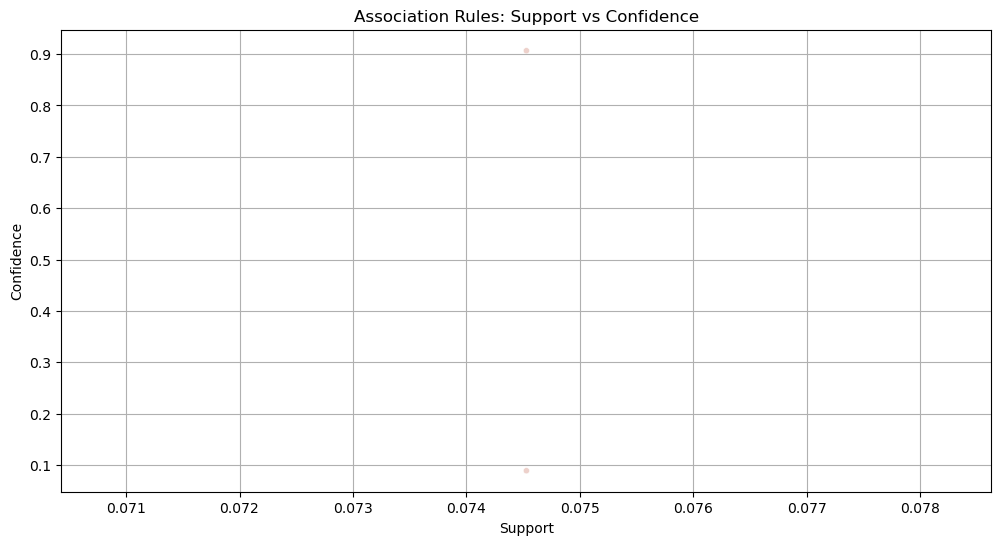

In [31]:
# Plot the results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', sizes=(20, 200), hue='lift', legend=False)
plt.title('Association Rules: Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid()
plt.show()

# Problem Statement 3: - 
A film distribution company wants to target audience based on their likes and dislikes, you as a Chief Data Scientist Analyze the data and come up with different rules of movie list so that the business objective is achieved.
3.) my_movies.csv


Business Objective:

The primary objective of the film distribution company is to maximize audience engagement and revenue by effectively targeting audiences based on their movie preferences.

Constraints:
    
Data Quality, Market Trends, Support Threshold

In [35]:
#import reuired libraries
import pandas as pd
import numpy as np
df=pd.read_csv("F:/Data science/Assignments/PCA assignment/my_movies.csv")

In [36]:
# Dataset Exploration and Data Dictionary
df.head(5)

,Sixth Sense,Gladiator,LOTR1,Harry Potter1,Patriot,LOTR2,Harry Potter2,LOTR,Braveheart,Green Mile
0,1,0,1,1,0,1,0,0,0,1
1,0,1,0,0,1,0,0,0,1,0
2,0,0,1,0,0,1,0,0,0,0
3,1,1,0,0,1,0,0,0,0,0
4,1,1,0,0,1,0,0,0,0,0


In [37]:
#shape
df.shape

(10, 10)

In [38]:
#describe dataset
df.describe()

,Sixth Sense,Gladiator,LOTR1,Harry Potter1,Patriot,LOTR2,Harry Potter2,LOTR,Braveheart,Green Mile
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,0.600000,0.700000,0.200000,0.200000,0.600000,0.200000,0.100000,0.100000,0.100000,0.200000
std,0.516398,0.483046,0.421637,0.421637,0.516398,0.421637,0.316228,0.316228,0.316228,0.421637
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [39]:
# Data Pre-processing
#Check for missing values
df.isnull().sum()

Sixth Sense      0
Gladiator        0
LOTR1            0
Harry Potter1    0
Patriot          0
LOTR2            0
Harry Potter2    0
LOTR             0
Braveheart       0
Green Mile       0
dtype: int64

In [40]:
#fill the missing values
df.fillna(0, inplace=True)

In [41]:
#Confirm that missing values are handled
print("\nAfter filling missing values:")
print(df.isnull().sum())


After filling missing values:
Sixth Sense      0
Gladiator        0
LOTR1            0
Harry Potter1    0
Patriot          0
LOTR2            0
Harry Potter2    0
LOTR             0
Braveheart       0
Green Mile       0
dtype: int64


In [42]:
#import necessary libraries to apply association rule
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [44]:
# Apply the Apriori algorithm
frequent_itemsets = apriori(df, min_support=0.1, use_colnames=True)  # Adjust min_support as needed
print(frequent_itemsets)

    support                                           itemsets
0       0.6                                      (Sixth Sense)
1       0.7                                        (Gladiator)
2       0.2                                            (LOTR1)
3       0.2                                    (Harry Potter1)
4       0.6                                          (Patriot)
5       0.2                                            (LOTR2)
6       0.1                                    (Harry Potter2)
7       0.1                                             (LOTR)
8       0.1                                       (Braveheart)
9       0.2                                       (Green Mile)
10      0.5                           (Sixth Sense, Gladiator)
11      0.1                               (LOTR1, Sixth Sense)
12      0.1                       (Harry Potter1, Sixth Sense)
13      0.4                             (Sixth Sense, Patriot)
14      0.1                               (Sixth Sense,

C:\Users\Sai\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [45]:
# Generate association rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

         antecedents                                      consequents  \
0      (Sixth Sense)                                      (Gladiator)   
1        (Gladiator)                                    (Sixth Sense)   
2      (Sixth Sense)                                        (Patriot)   
3          (Patriot)                                    (Sixth Sense)   
4             (LOTR)                                    (Sixth Sense)   
..               ...                                              ...   
233  (Harry Potter1)          (Green Mile, LOTR1, LOTR2, Sixth Sense)   
234          (LOTR1)  (Harry Potter1, Sixth Sense, LOTR2, Green Mile)   
235    (Sixth Sense)        (Harry Potter1, LOTR1, LOTR2, Green Mile)   
236          (LOTR2)  (Harry Potter1, LOTR1, Green Mile, Sixth Sense)   
237     (Green Mile)       (Harry Potter1, LOTR1, LOTR2, Sixth Sense)   

     support  confidence      lift  
0        0.5    0.833333  1.190476  
1        0.5    0.714286  1.190476  
2        0.4

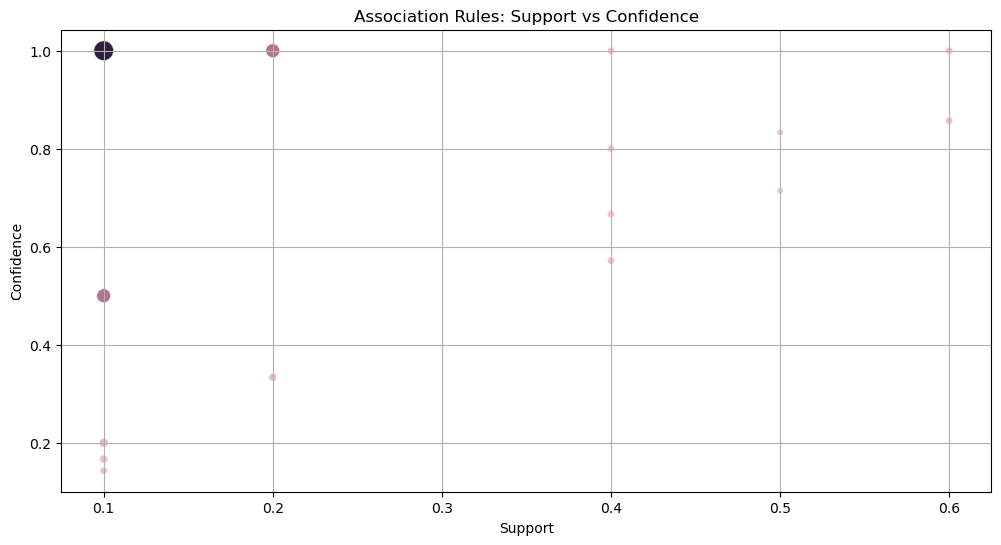

In [46]:
# Plot the results
plt.figure(figsize=(12, 6))
sns.scatterplot(data=rules, x='support', y='confidence', size='lift', sizes=(20, 200), hue='lift', legend=False)
plt.title('Association Rules: Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid()
plt.show()

Visualize the results of the association rules. You can create a scatter plot to represent the relationship between support, confidence, and lift